In [1]:
#!pip install iterative-stratification
#!pip install skorch

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy import signal
import scipy.io as sio
from scipy.linalg import toeplitz
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SKLDA
import torch.nn as nn
from xgboost import XGBClassifier
#from skorch import NeuralNetClassifier
import torch.nn.functional as F
import torch
from sklearn.preprocessing import RobustScaler
#from skorch.callbacks import Callback
from sklearn.base import BaseEstimator, ClassifierMixin
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
#from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

2025-10-20 05:41:43.439703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760938903.718811      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760938903.806816      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keys in MAT file: ['__header__', '__version__', '__globals__', 'value']
EMG data shape: (8, 8000)
Plot saved as 'emg_plot.png'. Description: Multi-channel sEMG plot with time on x-axis and amplitude on y-axis for each channel.


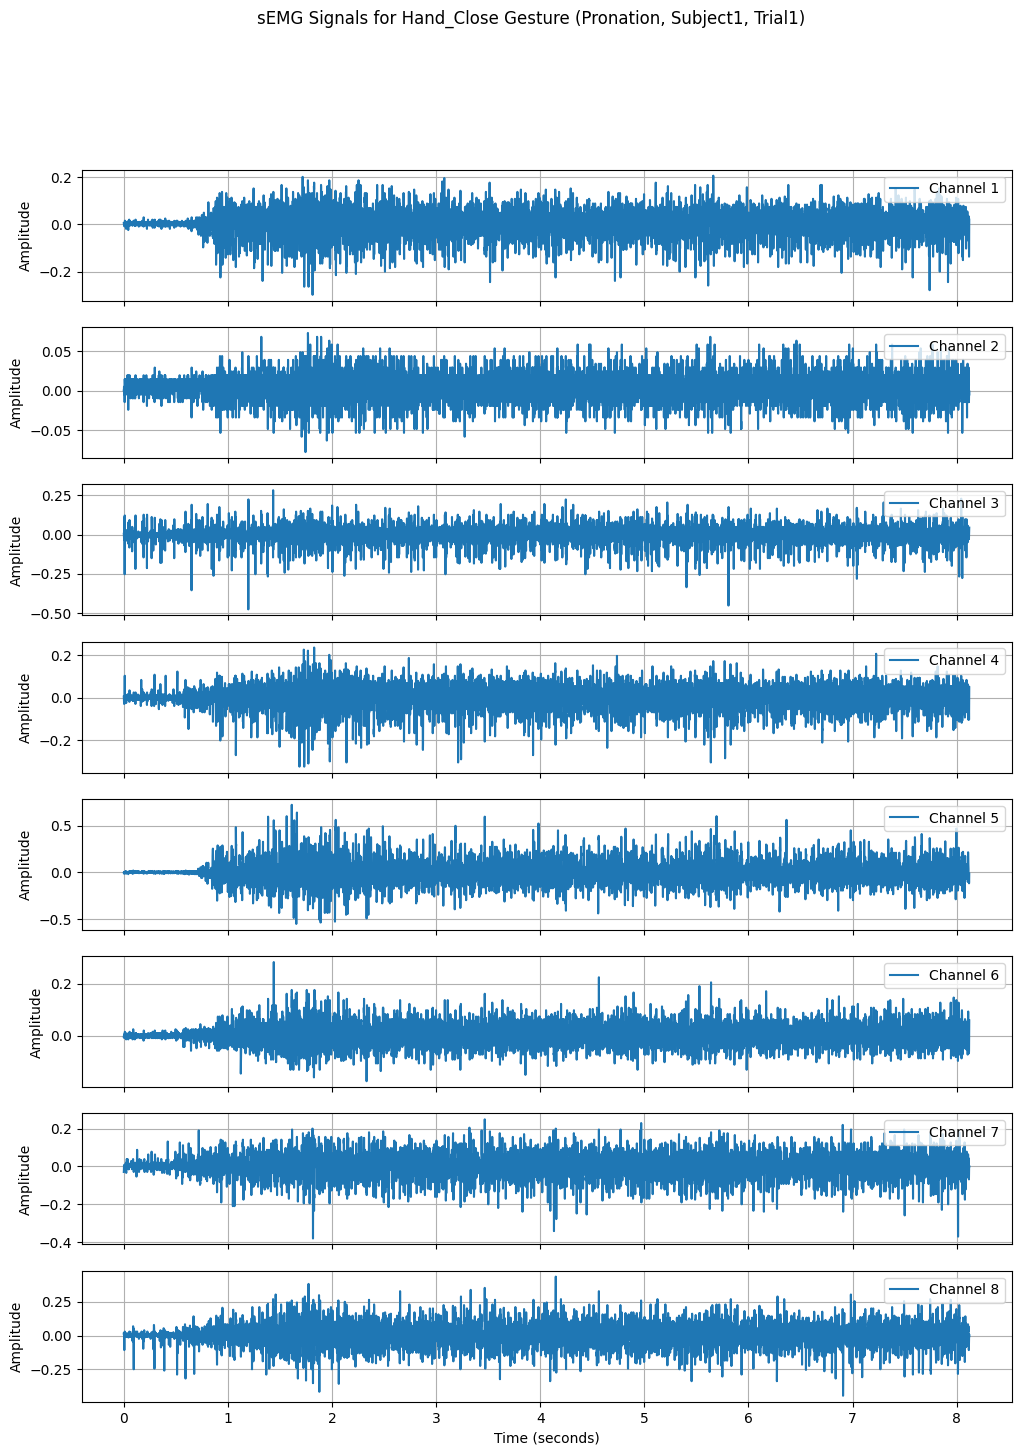

In [3]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import os

file_path = '/kaggle/input/fors-emg-a-novel-semg-dataset/FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG/Subject1/pronation/Index-2.mat'

if os.path.exists(file_path):
    mat = sio.loadmat(file_path)
    keys = list(mat.keys())
    print("Keys in MAT file:", keys)
    data_key = keys[-1]  # Assuming the last key is the data matrix
    emg_data = mat[data_key]
    print("EMG data shape:", emg_data.shape)
    
    # Assuming data is samples x channels, transpose if necessary
    if emg_data.shape[0] == 8000:
        emg_data = emg_data.T  # To channels x samples
    
    sample_rate = 985
    num_channels = emg_data.shape[0]
    num_samples = emg_data.shape[1]
    time = np.arange(num_samples) / sample_rate
    
    fig, axs = plt.subplots(num_channels, 1, figsize=(12, 2*num_channels), sharex=True)
    fig.suptitle('sEMG Signals for Hand_Close Gesture (Pronation, Subject1, Trial1)')
    
    for ch in range(num_channels):
        axs[ch].plot(time, emg_data[ch], label=f'Channel {ch+1}')
        axs[ch].set_ylabel('Amplitude')
        axs[ch].legend(loc='upper right')
        axs[ch].grid(True)
    
    axs[-1].set_xlabel('Time (seconds)')
    
    # Instead of plt.show(), save to a temp file and print description
    plt.savefig('emg_plot.png')
    print("Plot saved as 'emg_plot.png'. Description: Multi-channel sEMG plot with time on x-axis and amplitude on y-axis for each channel.")
else:
    print("File not found at:", file_path)

In [4]:
sample_rate = 985
window_size_ms = 250
stride_ms = 250
window_size = int(window_size_ms / 1000 * sample_rate)
stride = int(stride_ms / 1000 * sample_rate)
trial_duration = 8
samples_per_trial = trial_duration * sample_rate
num_channels = 8
num_grasps = 12
num_orientations = 3

notch_freq = 50.0 
q = 30.0

gestures = ['Thumb_Up', 'Index', 'Right_Angle', 'Peace', 'Index_Little', 'Thumb_Little', 'Hand_Close', 'Hand_Open', 'Wrist_Extension', 'Wrist_Flexion', 'Ulnar_Deviation', 'Radial_Deviation']
gesture_map = {g: i for i, g in enumerate(gestures)}
orientations = ['pronation', 'rest', 'supination']
orientation_map = {o: i for i, o in enumerate(orientations)}

upper_orientations = ['Pronation', 'Rest', 'Supination']
upper_orientation_map = {o: i for i, o in enumerate(upper_orientations)}

fs=985

In [ ]:
def detect_onset_and_offset(emg_trial, fs=985, rest_duration=2, threshold_factor=3, min_duration_ms=500, min_active_s=5, max_active_s=7):
    num_samples = emg_trial.shape[1]
    rest_samples = int(rest_duration * fs)
    if rest_samples >= num_samples:
        print('what the hell!') 
        return 0, num_samples

    rest_rms = np.sqrt(np.mean(emg_trial[:, :rest_samples]**2, axis=1))
    rest_mean = np.mean(rest_rms)
    rest_std = np.std(rest_rms)
    threshold = rest_mean + threshold_factor * rest_std

    window_size = int(0.05 * fs)  
    rms_signal = np.zeros(num_samples - window_size + 1)
    for ch in range(emg_trial.shape[0]):
        rms_signal += np.sqrt(np.convolve(emg_trial[ch]**2, np.ones(window_size) / window_size, mode='valid'))
    rms_signal /= emg_trial.shape[0]
    min_samples = int(min_duration_ms / 1000 * fs)

    onset = rest_samples
    for i in range(rest_samples, num_samples - min_samples):
        if np.all(rms_signal[i - rest_samples:i - rest_samples + min_samples] > threshold):
            onset = i - rest_samples + rest_samples  # Adjust index
            break

    offset = num_samples
    for i in range(len(rms_signal) - 1, -1, -1):
        if np.all(rms_signal[max(0, i - min_samples + 1):i + 1] > threshold):
            offset = i + window_size  # Adjust for window
            break

    duration_samples = offset - onset
    #print('duration samples: ', duration_samples)

    target_min = int(min_active_s * fs)
    target_max = int(max_active_s * fs)
    if duration_samples < target_min:
        offset = min(num_samples, onset + target_min)  # Extend if short
    elif duration_samples > target_max:
        offset = onset + target_max  # Truncate if long
    return onset, offset
    
def load_data_full(base_path='/kaggle/input/fors-emg-a-novel-semg-dataset/FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG'):
    X_list = []
    y_gesture_list = []
    y_orientation_list = []
    for subject in range(1, 20):
        subject_path = os.path.join(base_path, f'Subject{subject}')
        if subject != 1:
            new_orientations = ['Pronation', 'Rest', 'Supination']
        else:
            new_orientations = orientations
        for ori in new_orientations:
            ori_path = os.path.join(subject_path, ori)
            for gest in gestures:
                for trial in range(1, 6):
                    if gest == 'Thumb_Up':
                        rename_gest = 'Thumb_UP'
                    elif gest == 'Ulnar_Deviation':
                        rename_gest = 'Ulner_Deviation'
                    else:
                        rename_gest = gest
                    file_name = f'{rename_gest}-{trial}.mat'
                    file_path = os.path.join(ori_path, file_name)
                    mat = sio.loadmat(file_path)
                    emg_data = mat[list(mat.keys())[-1]]
                    #if emg_data.shape[0] == num_channels:
                    emg_trial = emg_data  
                    #elif emg_data.shape[1] == num_channels:
                    #emg_trial = emg_data.T
                    onset, offset = detect_onset_and_offset(emg_trial)
                    emg_trial = emg_trial[:, onset:offset]
                    X_list.append(emg_trial)
                    y_gesture_list.append(gesture_map[gest])
                    if subject != 1:
                        y_orientation_list.append(upper_orientation_map[ori])
                    else:
                        y_orientation_list.append(orientation_map[ori])
                        
    return X_list, np.array(y_gesture_list), np.array(y_orientation_list)

def load_data(base_path='/kaggle/input/fors-emg-a-novel-semg-dataset/FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG', subjects=None):
    if subjects is None:
        subjects = range(1, 20)
    X_list = []
    y_gesture_list = []
    y_orientation_list = []

    for subject in subjects:
        subject_path = os.path.join(base_path, f'Subject{subject}')
        if subject != 1:
            new_orientations = ['Pronation', 'Rest', 'Supination']
        else:
            new_orientations = orientations
        for ori in new_orientations:
            ori_path = os.path.join(subject_path, ori)
            for gest in gestures:
                for trial in range(1, 6):
                    if gest == 'Thumb_Up':
                        rename_gest = 'Thumb_UP'
                    elif gest == 'Ulnar_Deviation':
                        rename_gest = 'Ulner_Deviation'
                    else:
                        rename_gest = gest
                    file_name = f'{rename_gest}-{trial}.mat'
                    file_path = os.path.join(ori_path, file_name)
                    mat = sio.loadmat(file_path)
                    emg_data = mat[list(mat.keys())[-1]]
                    #if emg_data.shape[0] == num_channels:
                    emg_trial = emg_data  
                    #elif emg_data.shape[1] == num_channels:
                    #    emg_trial = emg_data.T
                    onset, offset = detect_onset_and_offset(emg_trial)
                    emg_trial = emg_trial[:, onset:offset]
                    X_list.append(emg_trial)
                    y_gesture_list.append(gesture_map[gest])
                    if subject != 1:
                        y_orientation_list.append(upper_orientation_map[ori])
                    else:
                        y_orientation_list.append(orientation_map[ori])

    #print("Load data function")
    #print(f"[DEBUG] Loaded {len(X_list)} EMG trials")
    #for i, seg in enumerate(X_list[:5]):  # only preview first 5
    #    print(f"   Trial {i} shape: {seg.shape}")
        
    return X_list, np.array(y_gesture_list), np.array(y_orientation_list)
            
def apply_bandpass(data, fs=sample_rate, low=20, high=450):
    sos = signal.butter(4, [low, high], btype='band', fs=fs, output='sos')
    filtered = signal.sosfiltfilt(sos, data, axis=1)
    return filtered

def apply_notch_filter(data, fs=sample_rate, freq=notch_freq, q=q):
    b, a = signal.iirnotch(freq, q, fs)
    filtered = signal.filtfilt(b, a, data, axis=1)
    return filtered

def offset_correction(data):
    return data - np.mean(data, axis=1, keepdims=True)

def extract_windows(data):
    num_samples = data.shape[1]
    windows = []
    for start in range(0, num_samples - window_size + 1, stride):
        window = data[:, start:start + window_size]
        windows.append(window)
    return np.array(windows)

def extract_tdd_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")

    num_channels, num_samples = window.shape
    #print('num channels: ', num_channels)
    #print('num samples: ', num_samples)
    features = []

    for ch in range(num_channels):
        signal = window[ch]
        diff1 = np.diff(signal)
        diff2 = np.diff(diff1)

        ssd1 = np.sum(diff1**2)
        ssd2 = np.sum(diff2**2)

        fft_vals = np.fft.rfft(signal)
        fft_power = np.abs(fft_vals) ** 2 / num_samples
        freqs = np.fft.rfftfreq(num_samples, d=1/fs)

        m0 = np.sum(fft_power) + 1e-8       
        m2 = np.sum((freqs**2) * fft_power)

        var_sig = np.var(signal)

        features.extend([ssd1, ssd2, m0, m2, var_sig])
        
    return np.array(features)

def extract_tsd_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")

    num_channels, num_samples = window.shape

    def compute_7_features(signal):
        fft_vals = np.fft.rfft(signal)
        fft_power = np.abs(fft_vals)**2 / num_samples
        freqs = np.fft.rfftfreq(num_samples, d=1/fs)

        m0 = np.sum(fft_power) + 1e-8
        m2 = np.sum(freqs**2 * fft_power) + 1e-8
        m4 = np.sum(freqs**4 * fft_power) + 1e-8

        l1 = np.sum(np.abs(signal))
        l2 = np.sqrt(np.sum(signal**2)) + 1e-8
        sparseness = (np.sqrt(num_samples) - (l1 / l2)) / (np.sqrt(num_samples) - 1)

        irregularity = np.sqrt((m4 / m2) - (m2 / m0)) if m2 > 0 else 0
        tkeo = np.mean(signal[1:-1]**2 - signal[:-2] * signal[2:]) if len(signal) > 2 else 0

        rms = np.sqrt(m0)
        mav = np.mean(np.abs(signal)) + 1e-8
        cov = rms / mav

        return np.array([m0, m2, m4, sparseness, irregularity, tkeo, cov])

    features = []
    for i in range(num_channels):
        signal = window[i]
        features.append(compute_7_features(signal))

    for i in range(num_channels):
        for j in range(i + 1, num_channels):
            diff_signal = window[i] - window[j]
            features.append(compute_7_features(diff_signal))

    return np.concatenate(features)

def extract_ftdd_features(window, fs=985):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")

    num_channels, num_samples = window.shape

    def compute_6_features(signal):

        fft_vals = np.fft.rfft(signal)
        fft_power = np.abs(fft_vals)**2 / num_samples
        freqs = np.fft.rfftfreq(num_samples, d=1/fs)

        m0 = np.sum(fft_power) + 1e-8
        m2 = np.sum(freqs**2 * fft_power) + 1e-8
        m4 = np.sum(freqs**4 * fft_power) + 1e-8
        m8 = np.sum(freqs**8 * fft_power) + 1e-8

        f1 = np.sqrt(m0)
        f2 = np.sqrt(m4)
        f3 = np.sqrt(m8)

        l1 = np.sum(np.abs(signal))
        l2 = np.sqrt(np.sum(signal**2)) + 1e-8
        sparseness = (np.sqrt(num_samples) - (l1 / l2)) / (np.sqrt(num_samples) - 1)

        irregularity = np.sqrt((m4 / m2) - (m2 / m0)) if m2 > 0 else 0

        diff1 = np.diff(signal)
        wl1 = np.sum(np.abs(np.diff(diff1))) if len(diff1) > 1 else 0

        diff2 = np.diff(diff1)
        wl2 = np.sum(np.abs(diff2)) if len(diff2) >  0 else 1e-8
        
        wl_ratio = wl1 / wl2

        return np.array([f1, f2, f3, sparseness, irregularity, wl_ratio])

    features = []
    for ch in range(num_channels):
        signal = window[ch]
        f_orig = compute_6_features(signal)
        signal_nl = np.log(signal**2 + 1e-8)
        f_nl = compute_6_features(signal_nl)
        fused = f_orig * f_nl
        features.append(fused)
        
    return np.concatenate(features)

def extract_ar_rms_features(window, order=6):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")

    features = []
    for ch in range(window.shape[0]):
        x = window[ch]
        # Yule-Walker AR coefficients
        r = np.correlate(x, x, mode="full")[len(x)-1:len(x)+order]
        R = toeplitz(r[:-1])
        rhs = r[1:]
        try:
            ar_coeffs = np.linalg.solve(R, rhs)
        except np.linalg.LinAlgError:
            print("except!!!!")
            ar_coeffs = np.zeros(order)
        rms = np.sqrt(np.mean(x**2))
        features.extend(np.concatenate([ar_coeffs, [rms]]))
    #print(type(features))
    return np.array(features)

def extract_hudgins_9_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")
        
    mav = np.mean(np.abs(window), axis=1)
    zc = np.sum(np.diff(np.sign(window), axis=1) != 0, axis=1)
    ssc = np.sum(np.diff(np.sign(np.diff(window, axis=1)), axis=1) != 0, axis=1)
    wl = np.sum(np.abs(np.diff(window, axis=1)), axis=1)

    rms = np.sqrt(np.mean(window**2, axis=1))
    var = np.var(window, axis=1)
    std = np.std(window, axis=1)
    kurt = np.mean(((window - np.mean(window, axis=1, keepdims=True)) / std[:, None])**4, axis=1)
    skew = np.mean(((window - np.mean(window, axis=1, keepdims=True)) / std[:, None])**3, axis=1)

    features = np.concatenate([mav, zc, ssc, wl, rms, var, std, kurt, skew])
    return features

def extract_hudgins_5_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")
        
    mav = np.mean(np.abs(window), axis=1)
    zc = np.sum(np.diff(np.sign(window), axis=1) != 0, axis=1)
    ssc = np.sum(np.diff(np.sign(np.diff(window, axis=1)), axis=1) != 0, axis=1)
    wl = np.sum(np.abs(np.diff(window, axis=1)), axis=1)

    features = np.concatenate([mav, zc, ssc, wl])
    return features

def extract_sntdf_features(window):
    
    mav_nl = np.log(np.mean(np.abs(window), axis=1) + 1e-8)
    power0 = np.mean(window**0, axis=1)
    power2 = np.mean(window**2, axis=1)
    power4 = np.mean(window**4, axis=1)
    power6 = np.mean(window**6, axis=1)

    diff1 = np.mean(np.abs(np.diff(window, axis=1)), axis=1)
    diff2 = np.mean(np.abs(np.diff(np.diff(window, axis=1), axis=1)), axis=1)

    corr = np.corrcoef(window)
    corr_flat = corr[np.triu_indices(num_channels, k=1)]  # Upper triangle
    features = np.concatenate([mav_nl, power0, power2, power4, power6, diff1, diff2, corr_flat])
    return features

def extract_combine_features(window):
    features_sntdf = extract_sntdf_features(window)
    features_hudgins = extract_hudgins_9_features(window)
    
    combined_features = np.concatenate([features_sntdf, features_hudgins])    
    return combined_features
  
def process_trial(emg_trial, features='hudgin_5'):
    #print('to process trial')
    bandpassed = apply_bandpass(emg_trial)
    filtered = apply_notch_filter(bandpassed)
    corrected = offset_correction(filtered)
    windows = extract_windows(corrected)
    if features=='hudgin_5':
        features = np.array([extract_hudgins_5_features(w) for w in windows])
    elif features=='hudgin_9':
        features = np.array([extract_hudgins_9_features(w) for w in windows])
    elif features == 'tdd':
        features = np.array([extract_tdd_features(w) for w in windows])
    elif features == 'tsd':
        features = np.array([extract_tsd_features(w) for w in windows])
    elif features == 'ftdd':
        features = np.array([extract_ftdd_features(w) for w in windows])
    elif features == 'ar_rms':
        #print('processing ar_rms')
        features = np.array([extract_ar_rms_features(w) for w in windows])
    elif features == 'sntdf':
        features = np.array([extract_sntdf_features(w) for w in windows])
    elif features == 'combine':
        features = np.array([extract_combine_features(w) for w in windows])
    return features

def prepare_dataset(X_list, y_gesture, y_orientation, features):
    features_list = []
    gesture_labels = []
    ori_labels = []
    for i, emg_trial in enumerate(X_list):
        feat = process_trial(emg_trial, features=features)
        num_windows = feat.shape[0]
        features_list.append(feat)
        gesture_labels.extend([y_gesture[i]] * num_windows)
        ori_labels.extend([y_orientation[i]] * num_windows)
    X = np.vstack(features_list)
    y_gesture = np.array(gesture_labels)
    y_orientation = np.array(ori_labels)
    return X, y_gesture, y_orientation

def normalize_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)
    return X_train_norm, X_test_norm

def srda_fit(X, y, alpha=1.0, n_components=None):
    
    classes, y_idx = np.unique(y, return_inverse=True)
    c = len(classes)
    if n_components is None:
        n_components = c - 1
    m, n = X.shape
    y0 = np.ones(m)
    Y = np.zeros((m, c))
    for i in range(c):
        Y[y_idx == i, i] = 1
    bar_Y = Y - np.mean(Y, axis=0)[np.newaxis, :] * y0[:, np.newaxis]
    bar_Y = bar_Y[:, :n_components]
    Q = np.zeros_like(bar_Y)
    for j in range(n_components):
        q = bar_Y[:, j]
        for i in range(j):
            q = q - np.dot(Q[:, i], bar_Y[:, j]) / np.dot(Q[:, i], Q[:, i]) * Q[:, i]
        Q[:, j] = q
    X_aug = np.hstack((X, np.ones((m, 1))))
    G = np.dot(X_aug.T, X_aug) + alpha * np.eye(n + 1)
    A = np.zeros((n + 1, n_components))
    for k in range(n_components):
        b = np.dot(X_aug.T, Q[:, k])
        A[:, k] = np.linalg.solve(G, b)
    return A

def srda_reduction(X, y=None, model=None, n_components=11, alpha=1.0):
    if model is None:
        if y is None:
            raise ValueError("y required for fit")
        model = srda_fit(X, y, alpha, n_components)
        X_aug = np.hstack((X, np.ones((X.shape[0], 1))))
        return np.dot(X_aug, model), model
    else:
        X_aug = np.hstack((X, np.ones((X.shape[0], 1))))
        return np.dot(X_aug, model)

def evaluate_lda(X, y, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)
    accs = []
    f1s = []
    for train_idx, val_idx in kf.split(X, y):
        clf = LinearDiscriminantAnalysis()
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[val_idx])
        accs.append(accuracy_score(y[val_idx], pred))
        f1s.append(f1_score(y[val_idx], pred, average='weighted'))
    return {'acc': np.mean(accs), 'f1': np.mean(f1s)}

def evaluate_svm(X, y, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)
    accs = []
    f1s = []
    for train_idx, val_idx in kf.split(X, y):
        clf = SVC(kernel='rbf', C=1.0, gamma='scale')
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[val_idx])
        accs.append(accuracy_score(y[val_idx], pred))
        f1s.append(f1_score(y[val_idx], pred, average='weighted'))
    return {'acc': np.mean(accs), 'f1': np.mean(f1s)}

def standard_classification(X, y_gesture, y_orientation, clf_type='lda'):
    results = {}
    #print('unique values of y_gesture: ')
    #print(set(y_gesture))
    for ori in np.unique(y_orientation):
        mask = (y_orientation == ori)
        X_ori = X[mask]
        y_ori_gesture = y_gesture[mask]
        #print('unique values of y_ori_gesture: ')
        #print(set(y_ori_gesture))
        #print(f"Position {pos}: {len(np.unique(y_pos_grasp))} grasp classes, {len(y_pos_grasp)} samples")
        
        if len(X_ori) == 0:
            print(f"Warning: No data for position {ori}")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(X_ori, y_ori_gesture, test_size=0.2, random_state=200, stratify=y_ori_gesture)
        #scaler = StandardScaler()
        #X_train = scaler.fit_transform(X_train)
        #X_test = scaler.transform(X_test)
        X_train, X_test = normalize_data(X_train, X_test)
        #print('unique values of y_train: ')
        #print(set(y_train))
        X_train, srda_model = srda_reduction(X_train, y_train) 
        X_test = srda_reduction(X_test, model=srda_model) 
        
        if clf_type == 'lda':
            cv_results = evaluate_lda(X_train, y_train)
            clf = LinearDiscriminantAnalysis()
        elif clf_type == 'svm':
            cv_results = evaluate_svm(X_train, y_train)
            clf = SVC(kernel='rbf', C=1.0, gamma='scale')
        elif clf_type == 'knn':
            clf = KNeighborsClassifier(n_neighbors=10, metric='euclidean')
            cv_results = {'acc': 0, 'f1': 0}  #placeholder
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        results[ori] = {"cv_acc": cv_results['acc'], "cv_f1": cv_results['f1'], "test_acc": test_acc, "test_f1": test_f1}
        
    return results

def naive_transfer(X, y_gesture, y_orientation, config_orientations=[0, 1, 2]):
    results_acc = np.zeros((len(config_orientations), len(config_orientations)))
    results_f1 = np.zeros((len(config_orientations), len(config_orientations)))

    for i, src in enumerate(config_orientations):
        mask_src = (y_orientation == src)
        X_src = X[mask_src]
        y_src = y_gesture[mask_src]
        if len(X_src) == 0:
            print('bruh')
            continue

        X_src_norm, _ = normalize_data(X_src, X_src)
        X_src_norm, srda_model = srda_reduction(X_src_norm, y_src)
        clf = LinearDiscriminantAnalysis()
        #clf = SVC(kernel='rbf', C=1.0, gamma='scale')
        clf.fit(X_src_norm, y_src)
        for j, tgt in enumerate(config_orientations):
            if i==j:
                #cv_results = evaluate_svm(X_src_norm, y_src)
                cv_results = evaluate_lda(X_src_norm, y_src)
                acc = cv_results['acc']
                f1 = cv_results['f1']
            else:
                mask_tgt = (y_orientation == tgt)
                X_tgt = X[mask_tgt]
                y_tgt = y_gesture[mask_tgt]
                if len(X_tgt) == 0:
                    continue
                _, X_tgt_norm = normalize_data(X_src, X_tgt)
                X_tgt_norm = srda_reduction(X_tgt_norm, model=srda_model) 
                pred = clf.predict(X_tgt_norm)
                acc = accuracy_score(y_tgt, pred)
                f1 = f1_score(y_tgt, pred, average='weighted')

            results_acc[i, j] = acc
            results_f1[i, j] = f1
    return {'acc_matrix': results_acc, 'f1_matrix': results_f1}

def orientation_classification(X, y_gesture, y_orientation, config_orientations=[0, 1, 2]):
    results = {}
    for gesture in range(len(gestures)):
        mask = (y_gesture == gesture) & np.isin(y_orientation, config_orientations)
        X_g = X[mask]
        y_g_ori = y_orientation[mask]
        if len(X_g) == 0:
            continue
        X_train, X_test, y_train, y_test = train_test_split(X_g, y_g_ori, test_size=0.2, random_state=200, stratify=y_g_ori)
        X_train, X_test = normalize_data(X_train, X_test)
        X_train, srda_model = srda_reduction(X_train, y_train, n_components=2)
        X_test = srda_reduction(X_test, model=srda_model) 
        #cv_results = evaluate_svm(X_train, y_train)
        cv_results = evaluate_lda(X_train, y_train)
        #clf = SVC(kernel='rbf', C=1.0, gamma='scale')
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        results[gesture] = {"cv_acc": cv_results['acc'], "cv_f1": cv_results['f1'], "test_acc": test_acc, "test_f1": test_f1}
    return results

class MLP128(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, n_classes=None, lr=1e-3, epochs=30, batch_size=32, verbose=0):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None
        self.loss_history = []

    def _build_model(self):
        model = Sequential()
        model.add(Dense(128, activation='relu', input_dim=self.input_dim))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(self.n_classes, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=self.lr),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
        return model

    def fit(self, X, y):
        if self.input_dim is None:
            self.input_dim = X.shape[1]
        if self.n_classes is None:
            self.n_classes = len(np.unique(y))
        y_cat = to_categorical(y, num_classes=self.n_classes)
        self.model = self._build_model()

        history = self.model.fit(
            X, y_cat,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose)
        self.loss_history = history.history['loss']  # 👈 Lưu loss
        return self

    def predict(self, X):
        preds = np.argmax(self.model.predict(X, verbose=0), axis=1)
        return preds

class MLP64(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, n_classes=None, lr=1e-3, epochs=30, batch_size=32, verbose=0):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None
        self.loss_history = []

    def _build_model(self):
        model = Sequential()
        model.add(Dense(64, activation='relu', input_dim=self.input_dim))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(self.n_classes, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=self.lr),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
        return model

    def fit(self, X, y):
        if self.input_dim is None:
            self.input_dim = X.shape[1]
        if self.n_classes is None:
            self.n_classes = len(np.unique(y))
        y_cat = to_categorical(y, num_classes=self.n_classes)
        self.model = self._build_model()

        history = self.model.fit(
            X, y_cat,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose)
        self.loss_history = history.history['loss']  # 👈 Lưu loss
        return self

    def predict(self, X):
        preds = np.argmax(self.model.predict(X, verbose=0), axis=1)
        return preds

class MLP48(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, n_classes=None, lr=1e-3, epochs=30, batch_size=32, verbose=0):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None
        self.loss_history = []

    def _build_model(self):
        model = Sequential()
        model.add(Dense(48, activation='relu', input_dim=self.input_dim))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(24, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(self.n_classes, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=self.lr),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
        return model

    def fit(self, X, y):
        if self.input_dim is None:
            self.input_dim = X.shape[1]
        if self.n_classes is None:
            self.n_classes = len(np.unique(y))
        y_cat = to_categorical(y, num_classes=self.n_classes)
        self.model = self._build_model()

        history = self.model.fit(
            X, y_cat,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose)
        self.loss_history = history.history['loss']  # 👈 Lưu loss
        return self

    def predict(self, X):
        preds = np.argmax(self.model.predict(X, verbose=0), axis=1)
        return preds

def mistelic(a, b, lam=0.5):
    return (a * b) / (lam + (1 - lam) * (a + b - a * b) + 1e-9)

def fuzzy_aggregate(probabilities, lam=0.5):
    agg = probabilities[..., 0]
    for i in range(1, probabilities.shape[2]):
        agg = mistelic(agg, probabilities[..., i], lam)
    return agg

'''
def fuzzy_ensemble(X_train, y_train, X_test, random_state=42, lam=0.5):
    svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=random_state)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=100,
        max_depth=4, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=random_state, verbosity=0)
    #mlp128 = MLP128(input_dim=X_train.shape[1], n_classes=len(np.unique(y_train)), epochs=30, verbose=0)
    #mlp64 = MLP64(input_dim=X_train.shape[1], n_classes=len(np.unique(y_train)), epochs=30, verbose=0)
    mlp48 = MLP48(input_dim=X_train.shape[1], n_classes=len(np.unique(y_train)), epochs=30, verbose=0)

    #mlp128.fit(X_train, y_train)
    svc.fit(X_train, y_train)
    xgb.fit(X_train, y_train)
    #mlp64.fit(X_train, y_train)
    mlp48.fit(X_train, y_train)

    #mlp128_train = mlp128.model.predict(X_train, verbose=0)
    #mlp64_train  = mlp64.model.predict(X_train, verbose=0)
    mlp48_train  = mlp48.model.predict(X_train, verbose=0)
    svc_train = svc.predict_proba(X_train)
    xgb_train = xgb.predict_proba(X_train)
    
    #mlp128_test = mlp128.model.predict(X_test, verbose=0)
    #mlp64_test = mlp64.model.predict(X_test, verbose=0)
    mlp48_test = mlp48.model.predict(X_test, verbose=0)
    svc_test = svc.predict_proba(X_test)
    xgb_test = xgb.predict_proba(X_test)

    scaler = MinMaxScaler()
    all_probs = np.concatenate([
        svc_train, xgb_train, mlp48_train,
        svc_test,  xgb_test,  mlp48_test
    ], axis=0).reshape(-1, 1)
    scaler.fit(all_probs)

    def normalize_stack(*models):
        stacked = np.stack(models, axis=2)
        normed = scaler.transform(stacked.reshape(-1, 1)).reshape(stacked.shape)
        return normed

    stacked_train = normalize_stack(svc_train, xgb_train, mlp48_train)
    stacked_test  = normalize_stack(svc_test,  xgb_test,  mlp48_test)

    fuzzy_train = fuzzy_aggregate(stacked_train, lam=lam)
    fuzzy_test  = fuzzy_aggregate(stacked_test,  lam=lam)

    y_pred_train = np.argmax(fuzzy_train, axis=1)
    y_pred_test  = np.argmax(fuzzy_test, axis=1)

    return y_pred_train, y_pred_test
'''

'''
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import mode
import numpy as np

def fuzzy_ensemble(X_train, y_train, X_test, random_state=42):
    # === Base models ===
    svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=random_state)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                        n_estimators=100, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=random_state, verbosity=0)
    mlp48 = MLP48(input_dim=X_train.shape[1],
                  n_classes=len(np.unique(y_train)),
                  epochs=30, verbose=0)

    # === Train ===
    svc.fit(X_train, y_train)
    xgb.fit(X_train, y_train)
    mlp48.fit(X_train, y_train)

    # === Predict hard labels ===
    svc_train = svc.predict(X_train)
    xgb_train = xgb.predict(X_train)
    mlp48_train = np.argmax(mlp48.model.predict(X_train, verbose=0), axis=1)

    svc_test = svc.predict(X_test)
    xgb_test = xgb.predict(X_test)
    mlp48_test = np.argmax(mlp48.model.predict(X_test, verbose=0), axis=1)

    # === Stack predictions ===
    preds_train = np.vstack([svc_train, xgb_train, mlp48_train]).T
    preds_test = np.vstack([svc_test, xgb_test, mlp48_test]).T

    # === Majority vote ===
    y_pred_train, _ = mode(preds_train, axis=1)
    y_pred_test, _ = mode(preds_test, axis=1)

    y_pred_train = y_pred_train.ravel()
    y_pred_test = y_pred_test.ravel()

    return y_pred_train, y_pred_test
'''

def meta_learner_ensemble(X_train, y_train, X_test, random_state=42, cv=4):
    # === Base models ===
    svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=random_state)
    xgb = XGBClassifier(
        use_label_encoder=False, eval_metric='mlogloss', n_estimators=100,
        max_depth=4, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=random_state, verbosity=0
    )
    mlp48 = MLP48(
        input_dim=X_train.shape[1], n_classes=len(np.unique(y_train)),
        epochs=30, verbose=0
    )

    base_models = [svc, xgb, mlp48]

    cv_split = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    oof_probas = np.zeros((X_train.shape[0], len(np.unique(y_train)) * len(base_models)))
    test_probas = np.zeros((X_test.shape[0], len(np.unique(y_train)) * len(base_models)))

    for i, model in enumerate(base_models):
        oof_fold_preds = np.zeros((X_train.shape[0], len(np.unique(y_train))))
        test_fold_preds = np.zeros((cv, X_test.shape[0], len(np.unique(y_train))))

        for j, (train_idx, val_idx) in enumerate(cv_split.split(X_train, y_train)):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            if isinstance(model, MLP48):
                model_fold = MLP48(input_dim=X_train.shape[1],
                                   n_classes=len(np.unique(y_train)),
                                   epochs=30, verbose=0)
                model_fold.fit(X_tr, y_tr)
                val_pred = model_fold.model.predict(X_val, verbose=0)
                test_pred = model_fold.model.predict(X_test, verbose=0)
            else:
                model_fold = model.__class__(**model.get_params())
                model_fold.fit(X_tr, y_tr)
                val_pred = model_fold.predict_proba(X_val)
                test_pred = model_fold.predict_proba(X_test)

            oof_fold_preds[val_idx] = val_pred
            test_fold_preds[j, :, :] = test_pred

        oof_probas[:, i * len(np.unique(y_train)):(i + 1) * len(np.unique(y_train))] = oof_fold_preds
        test_probas[:, i * len(np.unique(y_train)):(i + 1) * len(np.unique(y_train))] = test_fold_preds.mean(axis=0)

    scaler = MinMaxScaler()
    X_meta_train = scaler.fit_transform(oof_probas)
    X_meta_test  = scaler.transform(test_probas)

    meta_model = LogisticRegression(max_iter=500, random_state=random_state)
    meta_model.fit(X_meta_train, y_train)

    y_pred_train = meta_model.predict(X_meta_train)
    y_pred_test  = meta_model.predict(X_meta_test)

    return y_pred_train, y_pred_test
    
def hmc_classification(X, y_gesture, y_orientation, test_size=0.2, n_splits=5, random_state=200): 
    X_train, X_test, yg_train, yg_test, yo_train, yo_test = train_test_split(X, y_gesture, y_orientation, test_size=test_size, random_state=random_state, stratify=y_gesture)
    #y = np.vstack([y_gesture, y_orientation]).T
    #msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    #for train_idx, test_idx in msss.split(X, y):
    #    X_train, X_test = X[train_idx], X[test_idx]
    #    yg_train, yg_test = y_gesture[train_idx], y_gesture[test_idx]
    #    yo_train, yo_test = y_orientation[train_idx], y_orientation[test_idx]
        
    X_train_norm, X_test_norm = normalize_data(X_train, X_test)
    #X_train_norm, srda_model = srda_reduction(X_train_norm, yg_train)  
    #X_test_norm = srda_reduction(X_test_norm, model=srda_model)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    ori_cv_scores = []
    multi_label_cv_scores = []
    soft_cv_scores = []

    for train_idx, val_idx in kf.split(X_train_norm, yo_train):
        X_cv_train, X_cv_val = X_train_norm[train_idx], X_train_norm[val_idx]
        yg_cv_train, yg_cv_val = yg_train[train_idx], yg_train[val_idx]
        yo_cv_train, yo_cv_val = yo_train[train_idx], yo_train[val_idx]
        
        #clf_ori = SVC(kernel='rbf', C=1.0, gamma='scale')
        #clf_ori = LinearDiscriminantAnalysis()
        #clf_ori.fit(X_cv_train, yo_cv_train)

        #clf_ori = MLP(epochs=20, verbose=0)
        #clf_ori.fit(X_cv_train, yo_cv_train)

        #clf_ori = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=100, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=random_state, verbosity=0)
        #clf_ori.fit(X_cv_train, yo_cv_train)
        
        #print("Loss từng epoch:")
        #print(clf_ori.loss_history)

        temp, ori_pred_cv = meta_learner_ensemble(X_cv_train, yo_cv_train, X_cv_val)
        #ori_pred_cv = clf_ori.predict(X_cv_val)
        ori_cv_acc = accuracy_score(yo_cv_val, ori_pred_cv)
        ori_cv_scores.append(ori_cv_acc)
        
        std = np.std(ori_pred_cv) + 1e-8
        ori_pred_norm_cv = (ori_pred_cv - np.mean(ori_pred_cv)) / std
        X_aug_cv = np.hstack((X_cv_val, ori_pred_norm_cv.reshape(-1, 1)))
        #X_aug_train_cv = np.hstack((X_cv_train, ((clf_ori.predict(X_cv_train) - np.mean(clf_ori.predict(X_cv_train))) / (np.std(clf_ori.predict(X_cv_train)) + 1e-8)).reshape(-1, 1)))
        X_aug_train_cv = np.hstack((X_cv_train, ((temp - np.mean(temp)) / (np.std(temp) + 1e-8)).reshape(-1, 1)))

        gesture_clfs = {}
        unique_ori = np.unique(yo_cv_train)
        
        for ori in unique_ori:
            mask = (yo_cv_train == ori)
            X_ori_aug = X_aug_train_cv[mask]
            y_ori_gesture = yg_cv_train[mask]
            if len(np.unique(y_ori_gesture)) > 1:
                clf_g = LinearDiscriminantAnalysis()
                clf_g.fit(X_ori_aug, y_ori_gesture)
                gesture_clfs[ori] = clf_g
                
        preds_gesture = []
        soft_preds = []
        for i in range(len(X_cv_val)):
            o_pred = ori_pred_cv[i]
            x_aug = X_aug_cv[i].reshape(-1, X_aug_cv.shape[1])
            true_o = yo_cv_val[i]
            if o_pred in gesture_clfs:
                pred_g = gesture_clfs[o_pred].predict(x_aug)[0]
            else:
                print('bruh2')
                pred_g = np.argmax(np.bincount(yg_cv_train))
            preds_gesture.append(pred_g)
            if true_o in gesture_clfs:
                pred_g_soft = gesture_clfs[true_o].predict(x_aug)[0]
            else:
                print('bruh2')
                pred_g_soft = np.argmax(np.bincount(yg_cv_train))
            soft_preds.append(pred_g_soft)
        multi_label_acc = np.mean((ori_pred_cv == yo_cv_val) & (np.array(preds_gesture) == yg_cv_val))
        soft_acc = accuracy_score(yg_cv_val, soft_preds)
        multi_label_cv_scores.append(multi_label_acc)
        soft_cv_scores.append(soft_acc)
    cv_ori_acc = np.mean(ori_cv_scores)
    cv_multi_label_acc = np.mean(multi_label_cv_scores)
    cv_soft_acc = np.mean(soft_cv_scores)

    #clf_ori = SVC(kernel='rbf', C=1.0, gamma='scale')
    #clf_ori = LinearDiscriminantAnalysis()
    #clf_ori.fit(X_train_norm, yo_train)

    #clf_ori = MLP(epochs=20, verbose=0)
    #clf_ori.fit(X_train_norm, yo_train)

    #clf_ori = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=100, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=random_state, verbosity=0)
    #clf_ori.fit(X_train_norm, yo_train)

    #print("Loss từng epoch:")
    #print(clf_ori.loss_history)

    #ori_pred_test = clf_ori.predict(X_test_norm)
    temp_new, ori_pred_test = meta_learner_ensemble(X_train_norm, yo_train, X_test_norm)
    ori_acc = accuracy_score(yo_test, ori_pred_test)

    ori_pred_norm = (ori_pred_test - np.mean(ori_pred_test)) / (np.std(ori_pred_test) + 1e-8)
    X_aug_test = np.hstack((X_test_norm, ori_pred_norm.reshape(-1, 1)))
    #X_aug_train = np.hstack((X_train_norm,
    #    ((clf_ori.predict(X_train_norm) - np.mean(clf_ori.predict(X_train_norm))) / 
    #     (np.std(clf_ori.predict(X_train_norm)) + 1e-8)).reshape(-1, 1)))
    X_aug_train = np.hstack((X_train_norm,
        ((temp_new - np.mean(temp_new)) / 
         (np.std(temp_new) + 1e-8)).reshape(-1, 1)))

    gesture_clfs = {}
    unique_ori = np.unique(yo_train)
    for ori in unique_ori:
        mask = (yo_train == ori)
        X_ori_aug = X_aug_train[mask]
        y_ori_gesture = yg_train[mask]
        if len(np.unique(y_ori_gesture)) > 1:
            clf_g = LinearDiscriminantAnalysis()
            clf_g.fit(X_ori_aug, y_ori_gesture)
            gesture_clfs[ori] = clf_g

    preds_gesture = []
    soft_preds = []
    for i in range(len(X_test_norm)):
        o_pred = ori_pred_test[i]
        x_aug = X_aug_test[i].reshape(1, -1)
        true_o = yo_test[i]

        if o_pred in gesture_clfs:
            pred_g = gesture_clfs[o_pred].predict(x_aug)[0]
        else:
            print('bruh2')
            pred_g = np.argmax(np.bincount(yg_train))
            
        preds_gesture.append(pred_g)
        
        if true_o in gesture_clfs:
            pred_g_soft = gesture_clfs[true_o].predict(x_aug)[0]
        else:
            print('bruh2')
            pred_g_soft = np.argmax(np.bincount(yg_train))
            
        soft_preds.append(pred_g_soft)
        
    multi_label_acc = np.mean((ori_pred_test == yo_test) & (np.array(preds_gesture) == yg_test))
    soft_acc = accuracy_score(yg_test, soft_preds)

    return cv_ori_acc, cv_multi_label_acc, cv_soft_acc, ori_acc, multi_label_acc, soft_acc  
        
def run_pipeline(subjects=[1], features='sntdf'):
    X_list, y_gesture, y_orientation = load_data(subjects=subjects)
    #print('unique values of y_gesture after load data: ')
    #print(set(y_gesture))
    X, y_gesture, y_orientation = prepare_dataset(X_list, y_gesture, y_orientation, features=features) 
    #print('unique values of y_gesture after prepare dataset: ')
    #print(set(y_gesture))
    print("len(X): ", len(X))
    config = [0, 1, 2]
    standard_results = standard_classification(X, y_gesture, y_orientation)
    transfer_results = naive_transfer(X, y_gesture, y_orientation, config)
    ori_class_results = orientation_classification(X, y_gesture, y_orientation, config)
    #hmc_results = hmc_classification(X, y_gesture, y_orientation)
    return {'standard': standard_results, 'transfer': transfer_results, 'ori_class': ori_class_results}

def run_pipeline_hmc(subjects=[1], features='sntdf'):
    X_list, y_gesture, y_orientation = load_data(subjects=subjects)
    X, y_gesture, y_orientation = prepare_dataset(X_list, y_gesture, y_orientation, features=features)
    print("Data shape:", X.shape, "Unique orientations:", np.unique(y_orientation))
    hmc_results = hmc_classification(X, y_gesture, y_orientation)
    return {'hmc': hmc_results}

In [9]:
all_results_hmc = []

for subjects in range(1, 20):
    results_hmc = run_pipeline_hmc(subjects=[subjects], features='combine')
    # results_hmc['hmc'] là tuple
    all_results_hmc.append(results_hmc['hmc'])

all_results_hmc = np.array(all_results_hmc)

cv_pos_accs        = all_results_hmc[:, 0]
cv_multi_label_accs = all_results_hmc[:, 1]
cv_soft_accs        = all_results_hmc[:, 2]
pos_accs           = all_results_hmc[:, 3]
multi_label_accs   = all_results_hmc[:, 4]
soft_accs          = all_results_hmc[:, 5]

print("run_pipeline_hmc mean CV Position Acc:", np.mean(cv_pos_accs))
print("run_pipeline_hmc mean CV Multi-label Acc:", np.mean(cv_multi_label_accs))
print("run_pipeline_hmc mean CV Soft Acc:", np.mean(cv_soft_accs))
print("run_pipeline_hmc mean Test Position Acc:", np.mean(pos_accs))
print("run_pipeline_hmc mean Test Multi-label Acc:", np.mean(multi_label_accs))
print("run_pipeline_hmc mean Test Soft Acc:", np.mean(soft_accs))

Data shape: (4311, 156) Unique orientations: [0 1 2]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-20 05:42:45.569556: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When u

Data shape: (4320, 156) Unique orientations: [0 1 2]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Data shape: (4312, 156) Unique orientations: [0 1 2]


...

Data shape: (4304, 156) Unique orientations: [0 1 2]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Data shape: (4294, 156) Unique orientations: [0 1 2]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

run_pipeline_hmc mean CV Position Acc: 0.9538449788376757
run_pipeline_hmc mean CV Multi-label Acc: 0.9461876149318049
run_pipeline_hmc mean CV Soft Acc: 0.9911868563850778
run_pipeline_hmc mean Test Position Acc: 0.9575563517132759
run_pipeline_hmc mean Test Multi-label Acc: 0.9335021207702354
run_pipeline_hmc mean Test Soft Acc: 0.9744137551624382
